Temperatura de entrada: 35 °C
Potência recomendada pelo sistema fuzzy: 50.00%


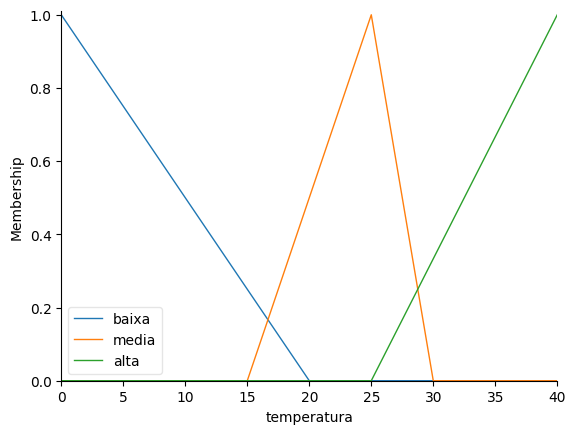

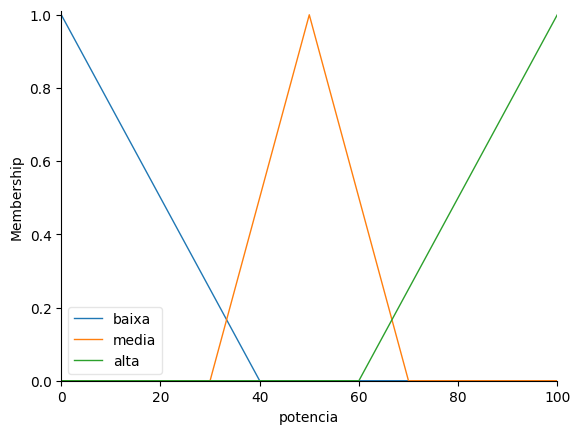

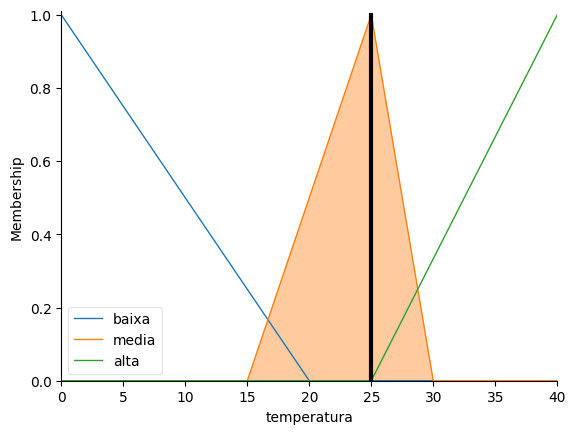

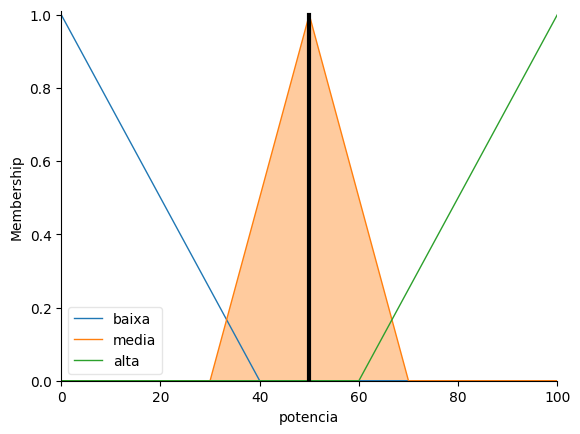

In [ ]:
# ===============================================================
# SISTEMA FUZZY SISO - CONTROLE DE AR-CONDICIONADO
# ---------------------------------------------------------------
# Linguagem: Python
# Biblioteca: scikit-fuzzy (skfuzzy)
# ===============================================================
#!pip install scikit-fuzzy
# ---------------------------------------------------------------
# Importação das bibliotecas necessárias
# ---------------------------------------------------------------
# numpy -> manipulação de arrays numéricos
# skfuzzy -> criação e simulação do sistema fuzzy
# matplotlib -> visualização dos conjuntos fuzzy
import numpy as np
import skfuzzy as fuzzy
import skfuzzy.control as ctrl
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Definição das VARIÁVEIS LINGUÍSTICAS
# ---------------------------------------------------------------
# Na Lógica Fuzzy, usamos termos linguísticos (como "quente", "frio", "médio")
#    para representar variáveis contínuas que não têm fronteiras exatas.
#
#    Em Python, usamos:
#      - ctrl.Antecedent → variável de ENTRADA (causa)
#      - ctrl.Consequent → variável de SAÍDA (efeito)
#
#    Em lógica, "antecedente" é a parte do "SE" (condição)
#    e "consequente" é a parte do "ENTÃO" (resposta).
#
# Exemplo de regra:
#   SE Temperatura é Alta (Antecedent)
#   ENTÃO Potência do ar é Alta (Consequent)

# Criando a variável de entrada (temperatura ambiente, 0°C a 40°C)
temperatura = ctrl.Antecedent(np.arange(0, 41, 1), 'temperatura')

# Criando a variável de saída (potência do ar-condicionado, 0% a 100%)
potencia = ctrl.Consequent(np.arange(0, 101, 1), 'potencia')

# ---------------------------------------------------------------
# Definição das FUNÇÕES DE PERTINÊNCIA (membership functions)
# ---------------------------------------------------------------
# Cada conjunto fuzzy (ex: “temperatura baixa”) é representado
# por uma função de pertinência, que indica o quanto um valor pertence
# a esse conjunto (grau entre 0 e 1).
#
# Aqui usamos a função "trimf" = triangular membership function,
# uma forma simples e muito usada para sistemas didáticos.
#
# Por que usamos "trimf"?
#   ✔ Fácil de entender (três pontos formam um triângulo)
#   ✔ Boa aproximação para transições suaves
#   ✔ Simples para iniciar o estudo
#
# Por que não trapezoidal (“trapmf”)?
#   - A função trapezoidal é parecida, mas tem um topo plano.
#   - Ela é útil quando queremos zonas de estabilidade maiores.
#   - Aqui queremos uma transição mais direta e simples, então usamos triângulos.

# Definindo os conjuntos fuzzy da variável de entrada (Temperatura)
temperatura['baixa']  = fuzzy.trimf(temperatura.universe, [0, 0, 20])
temperatura['media']  = fuzzy.trimf(temperatura.universe, [15, 25, 30])
temperatura['alta']   = fuzzy.trimf(temperatura.universe, [25, 40, 40])

# Significado dos parâmetros em trimf(universe, [a, b, c]):
#   - "a" = ponto onde a função começa a subir (grau 0)
#   - "b" = ponto de máximo (grau 1)
#   - "c" = ponto onde volta para 0
#
# Exemplo: [0, 0, 20] → começa em 0, tem máximo em 0, e volta a 0 em 20.

# Definindo os conjuntos fuzzy da variável de saída (Potência)
potencia['baixa'] = fuzzy.trimf(potencia.universe, [0, 0, 40])
potencia['media'] = fuzzy.trimf(potencia.universe, [30, 50, 70])
potencia['alta']  = fuzzy.trimf(potencia.universe, [60, 100, 100])


# ---------------------------------------------------------------
# Visualizar as funções de pertinência
# ---------------------------------------------------------------
# .view() → exibe graficamente as funções fuzzy.
# Isso ajuda a entender as regiões de "baixa", "média" e "alta".
temperatura.view()
potencia.view()


# ---------------------------------------------------------------
# Definir as REGRAS FUZZY (If–Then)
# ---------------------------------------------------------------
# As regras fuzzy são a base do raciocínio.
# Elas modelam o conhecimento humano em linguagem natural.
#
# Sintaxe:
#   ctrl.Rule( <condição>, <consequência> )
#
# Aqui temos três regras simples:

regra1 = ctrl.Rule(temperatura['baixa'], potencia['baixa'])
regra2 = ctrl.Rule(temperatura['media'], potencia['media'])
regra3 = ctrl.Rule(temperatura['alta'],  potencia['alta'])

# Interpretação:
#   Regra 1 → SE temperatura é baixa, ENTÃO potência é baixa.
#   Regra 2 → SE temperatura é média, ENTÃO potência é média.
#   Regra 3 → SE temperatura é alta, ENTÃO potência é alta.


# ---------------------------------------------------------------
# Criação do SISTEMA DE CONTROLE difuso
# ---------------------------------------------------------------
# As regras são reunidas dentro de um "ControlSystem".
# Este sistema é o cérebro fuzzy que processa as entradas e gera saídas.
sistema_ctrl = ctrl.ControlSystem([regra1, regra2, regra3])
# Criamos um objeto de simulação (ControlSystemSimulation)
# Ele será responsável por calcular as saídas com base nas entradas.
simulador = ctrl.ControlSystemSimulation(sistema_ctrl)


# ======================================================
# Entrada de dados (valor "crisp" do sensor)
# ======================================================
# Exemplo: sensor detecta temperatura ambiente de 35 °C
simulador.input['temperatura'] = 25
# ======================================================
# Execução da INFERÊNCIA FUZZY
# ======================================================
simulador.compute()  # O sistema calcula automaticamente a saída
# ======================================================
# Resultados
# ======================================================
print(f"Temperatura de entrada: 35 °C")
print(f"Potência recomendada pelo sistema fuzzy: {simulador.output['potencia']:.2f}%")

# ---------------------------------------------------------------
# Visualização do processo de inferência
# ---------------------------------------------------------------
# Aqui podemos ver, graficamente, como o sistema chegou ao resultado.
temperatura.view(sim=simulador)
potencia.view(sim=simulador)
plt.show()
